In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Exercise 3 - Orbits.

Consider a rod of length $L$, negligible cross-section, and mass $M$, and a sphere of mass $m$ floating under zero gravity. 
Assume that $M\gg m$, so that the motion of the rod is negligible and that the sphere orbits around the midpoint of the rod in a plane perpendicular to its length. 

1. Show that the gravitational force on the sphere in the direction pointing to the center of the rod is given by

    $$F=\frac{GMm}{L}\sqrt{x^2+y^2}\int\limits_{-L/2}^{L/2}\frac{{\text d}z}{\left(x^2+y^2+z^2\right)^{3/2}},$$

    where $G$ is the gravitational constant, and $x$ and $y$ are the coordinates of the sphere in the plane perpendicular to the rod. 

2. Perform the integral analytically and show that the force can be written as

    $$F=\frac{GMm}{\sqrt{(x^2+y^2)(x^2+y^2+L^2/4)}},$$

    so that the equations of motion are

    $$\frac{\text{d}^2x}{\text{d}t^2}=-GM\frac{x}{r^2\sqrt{r^2+L^2/4}},\quad \frac{\text{d}^2y}{\text{d}t^2}=-GM\frac{y}{r^2\sqrt{r^2+L^2/4}},$$

    with $r=\sqrt{x^2+y^2}$.

3. Solve the equations using units in which $G=1$, $M=10$, $L=2$, with initial conditions $(x,y)=(1,0)$ and velocity 1 in the $y$ direction.  
   Compute the orbit in the interval $t\in[0,10]$ and plot the trajectory in the $xy$ plane.   
   Why is the motion different from that of a planet orbiting the Sun?


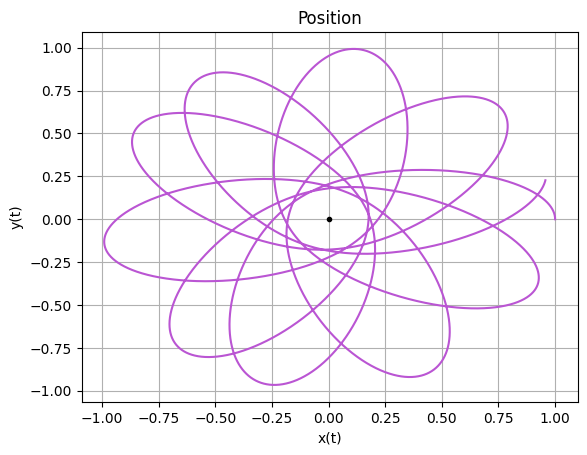

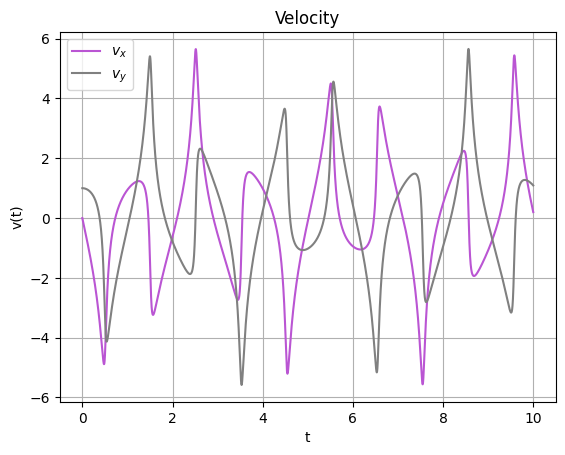

In [10]:
def F(r, t):
    x = r[0]
    y = r[1]
    vx = r[2]
    vy = r[3]

    fx = vx
    fy = vy

    M, L, G = 10, 2, 1
    r2 = x**2 + y**2
    denom = r2 * np.sqrt(r2 + (L**2) / 4)

    fvx = -M * G * x / denom
    fvy = -M * G * y / denom

    return np.array([fx, fy, fvx, fvy], float)


def rk4_system_2o(F, a, b, N, r):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    yp = []
    vxp = []
    vyp = []
    r = np.array(r, float)

    for t in tp:
        xp.append(r[0])
        yp.append(r[1])
        vxp.append(r[2])
        vyp.append(r[3])

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)

        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    return tp, xp, yp, vxp, vyp


a, b, N = 0, 10, 10000
initial_conditions = [1, 0, 0, 1]

t, x, y, vx, vy = rk4_system_2o(F, a, b, N, initial_conditions)

plt.plot(x, y, color = mc)
plt.plot(0, 0, ".k")
plt.grid()
plt.title('Position')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.show()

plt.plot(t, vx, color = mc)
plt.plot(t, vy, color = 'gray')
plt.legend(["$v_x$", "$v_y$"])
plt.grid()
plt.title('Velocity')
plt.ylabel('v(t)')
plt.xlabel('t')
plt.show()